<a href="https://colab.research.google.com/github/Olivia-Yoob/Time-Series-Forecasting-with-Python/blob/main/Back%20Test%20ETS%20and%20ARIMA%20Time%20Series%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Back Test ETS and ARIMA Time Series Models

---

## Problem Definition

Predict and back test monthly anti-diabetic drug sales in Australia, using the 204 monthly observations from July 1991 to June 2008.

Twelve-month forecasts are back tested over four consecutive test periods — July 2004–June 2005, July 2005–June 2006, July 2006–June 2007, and July 2007–June 2008. For each period every model is
re-fitted on data ending the month before that period begins, so no model is ever trained on the window it is asked to forecast.

Multiple ETS and ARIMA models are compared across the four periods, plotted against the observed test data, and one model is selected to forecast the next 12 months.


## Read in the appropriate packages

In [ ]:
!pip install pmdarima

In [ ]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA
import pmdarima as pm #auto arima

# White Noise Refresher

In summary:

1. White noise time series is defined by a zero mean, constant variance, and no correlation with past lags.
2. If your time series is white noise, it cannot be predicted, and if your forecast residuals are not white noise, you may be able to improve your model.
3. Descriptive statistics and plots such as autocorrelation, line plots, and residual plots can be used on your time series to check if it is white noise.


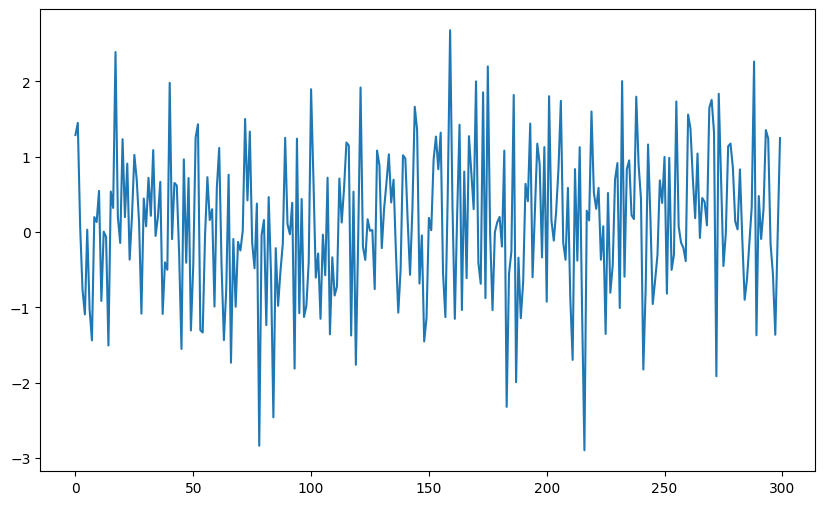

In [ ]:
# Let us create a Gaussian White Noise series
# Create a list of 300 random Gaussian variables using the gauss() function
# Draw variables from a Gaussian distribution with a mean (mu) of 0.0 and a standard deviation (sigma) of 1.0.

# seed random number generator
seed(1)
# create white noise series
series = [gauss(0.0, 1.0) for i in range(300)]
series = Series(series)

# line plot
plt.figure(figsize=(10,6))
series.plot()
plt.show()

In [ ]:
series.describe()

,0
count,300.000000
mean,0.115328
std,0.970553
min,-2.896251
25%,-0.506559
50%,0.131935
75%,0.789927
max,2.678687


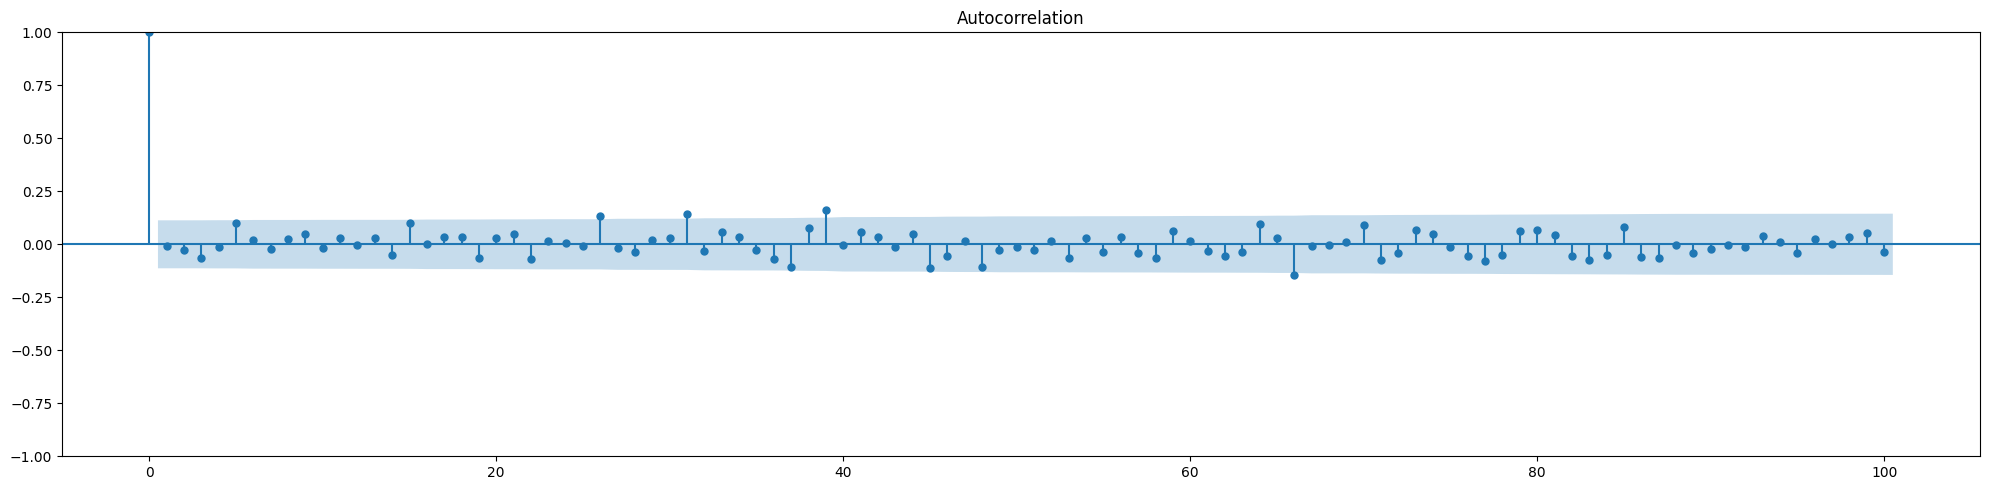

In [ ]:
# autocorrelation plot - correlation between lagged variables - see excel sheet
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(series, lags=100)
fig.set_size_inches((20, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Read in the monthly anti-diabetic drug sales in Australia dataset

Download the data from the the gdrive: https://drive.google.com/file/d/1Lm58Ktv-n1tv_JxOSVJfCQE123Xtoctv/view?usp=sharing

In [ ]:
drug_sales_df = pd.read_csv('/content/drive/MyDrive/Time Series Forecasting with Python/drug_sales_australia.csv',
                            parse_dates=['date'],
                            index_col=['date'])

drug_sales_df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


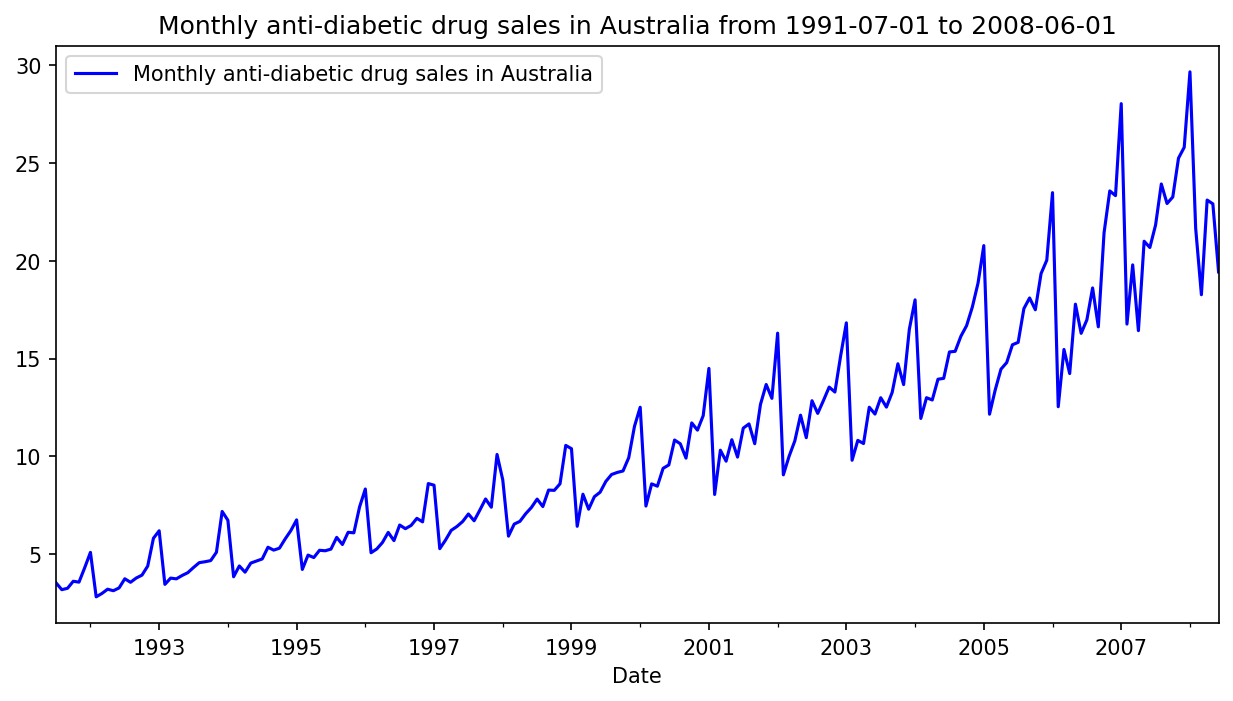

In [ ]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
drug_sales_df['value'].plot(label='Monthly anti-diabetic drug sales in Australia', color='blue')

# adding title to the plot
plt.title('Monthly anti-diabetic drug sales in Australia from {} to {}'.format('1991-07-01', '2008-06-01'))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


In [ ]:
#questions
#1. Is this white noise?
#1. trend or seasonality?
#2. additive or multiplicative trend and seasonality?


In [ ]:
drug_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 1991-07-01 to 2008-06-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   204 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


## 2. Exploratory Data Analysis (EDA)


In [ ]:
# 1. Descriptive Statistics
drug_sales_df.describe()

,value
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


<Axes: >

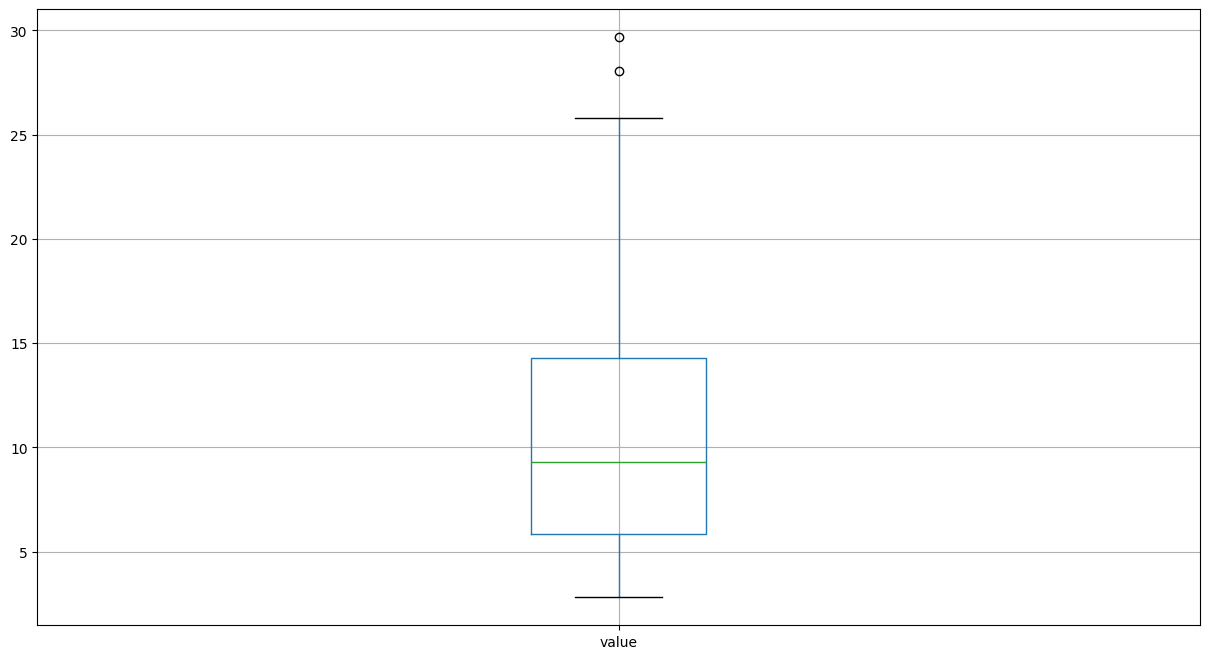

In [ ]:
plt.figure(figsize=(15,8))
drug_sales_df.boxplot()

In [ ]:
# 2. Check for missing values
drug_sales_df.isnull().sum()

,0
value,0


In [ ]:
# 3. Find the indexes that are missing
pd.date_range(start = drug_sales_df.index.min(), end = drug_sales_df.index.max(), freq='MS').difference(drug_sales_df.index)


DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

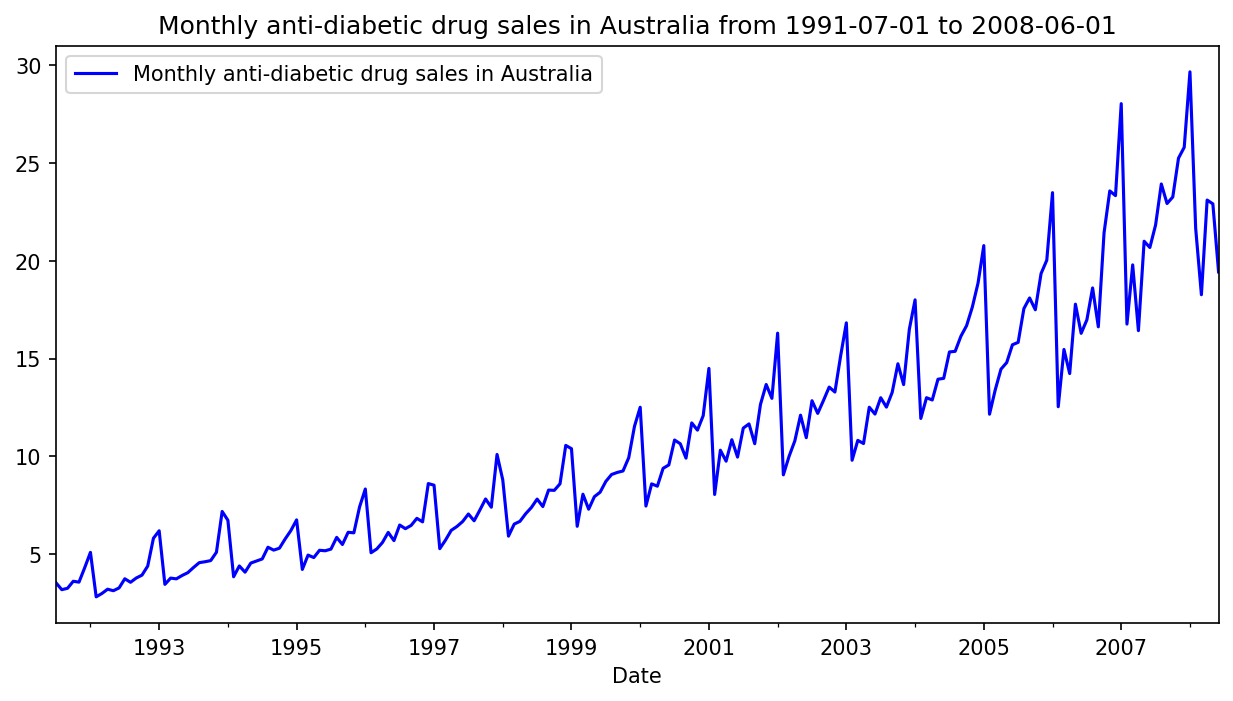

In [ ]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
drug_sales_df['value'].plot(label='Monthly anti-diabetic drug sales in Australia', color='blue')

# adding title to the plot
plt.title('Monthly anti-diabetic drug sales in Australia from {} to {}'.format('1991-07-01', '2008-06-01'))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


## Stationarity  

### Why Does Stationarity Matter in Time Series Analysis? Why do we have to make sure our data set is stationary before we can run different ARIMA models on it?

Stationarity is crucial in time series analysis because it ensures that the statistical properties of a time series remain constant over time. By removing trends and seasonality, stationarity allows us to focus on the underlying dynamics and capture autocorrelation effectively. ARIMA models assume stationarity and rely on it to make reliable predictions. Ensuring stationarity before applying ARIMA models is necessary to meet model assumptions and obtain accurate results.

1. Consider the forecasting problem. How do you forecast? If everything's different tomorrow then it's impossible to forecast, because everything's going to be different. So the key to forecasting is to find something that will be the same tomorrow, and extend that to tomorrow. Hence, a stationarized series is relatively easy to predict.

2. Statistical modeling methods assume or require the time series to be stationary to be effective. The ARIMA models predict that the mean and variance will be the same in the future as they have been in the past. A stationary time series will also allow us to obtain meaningful statistics such as means, variances, and correlations with other variables. These stats are only useful descriptors if the series is stationary.

3. As in the case of the monthly anti-diabetic drug sales, the series is consistently increasing over time. Hence, the sample mean and variance will grow with the size of the sample and the models will always underestimate the mean and variance in the future periods.

Ssource: https://towardsdatascience.com/why-does-stationarity-matter-in-time-series-analysis-e2fb7be74454

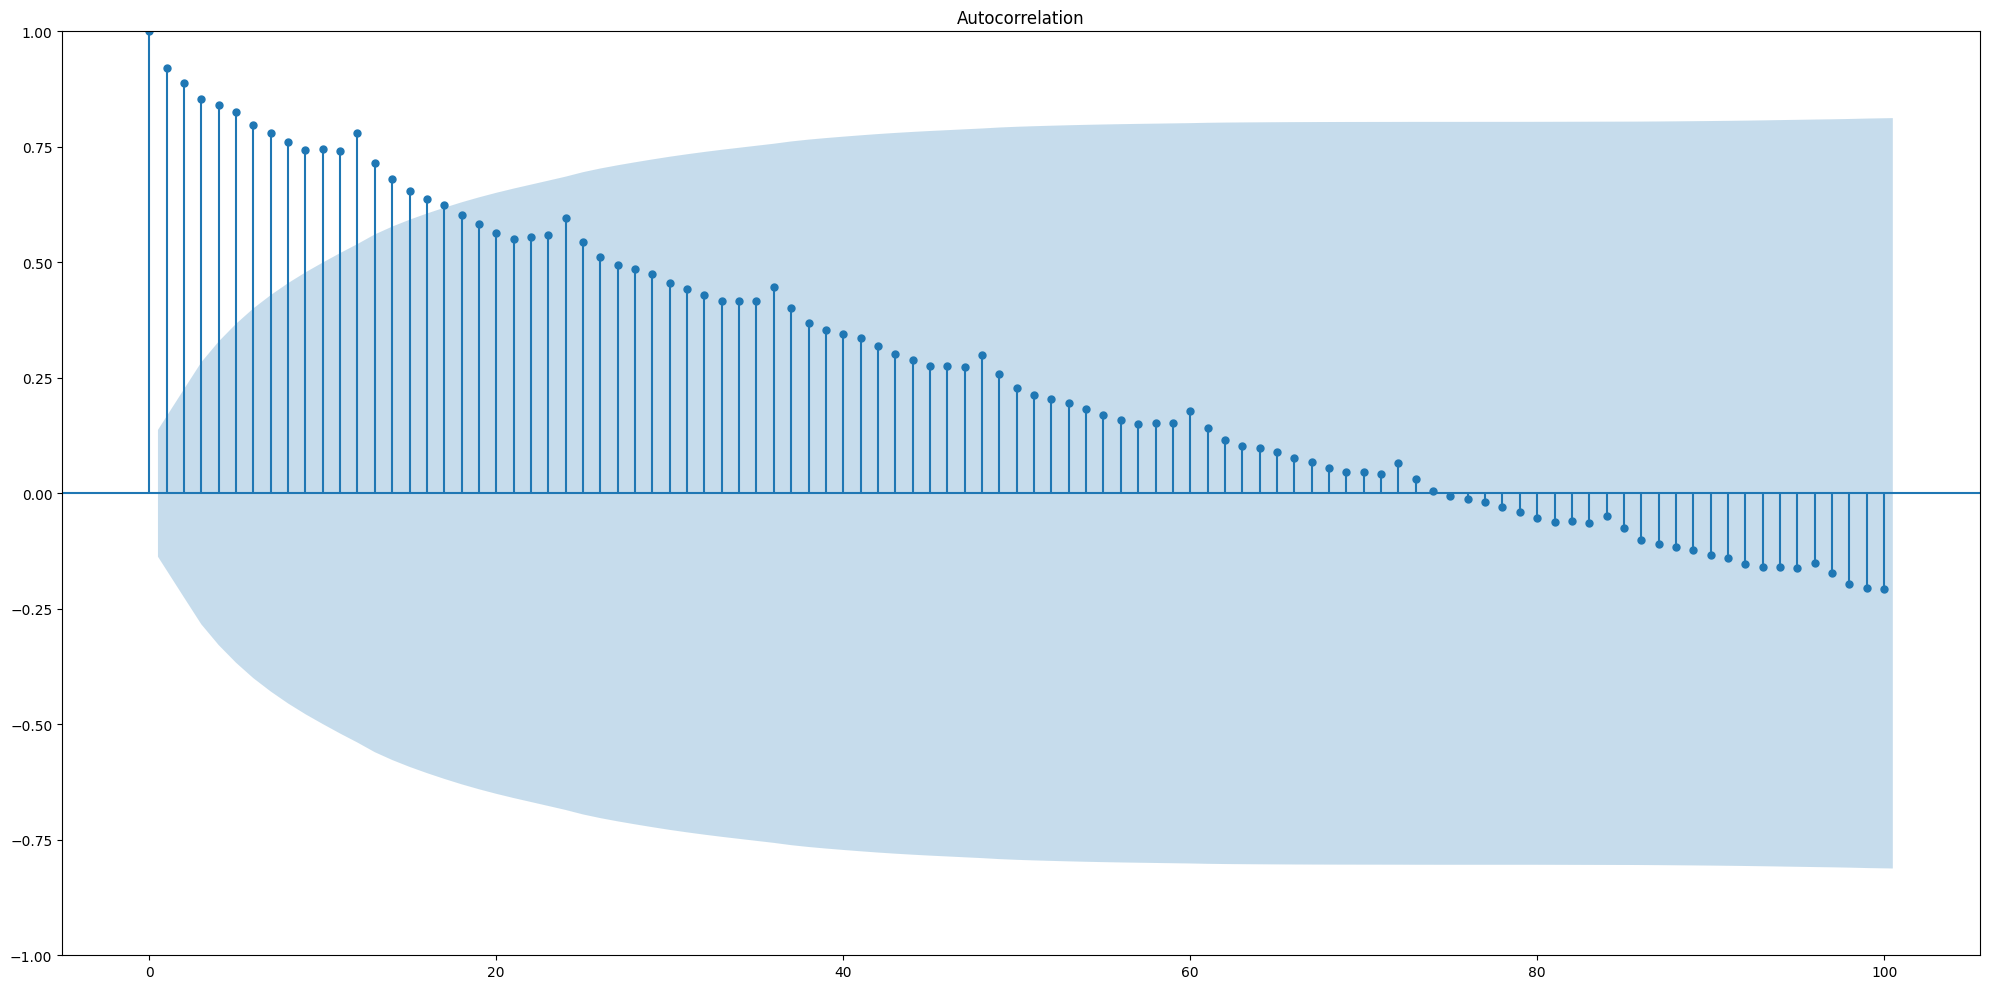

In [ ]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(drug_sales_df, lags=100)
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [ ]:
#data has trend as well as seasonlity of 12 months

## Unit Root Test - Augmented Dickey-Fuller (ADF) statistical test to check stationarity

In [ ]:
# let's check it for our time series

In [ ]:
X = drug_sales_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 3.145186
p-value: 1.000000
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575


/tmp/ipykernel_4076/3821393100.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Running the test prints the test statistic value of 3.14. The more negative this statistic, the more likely we are to reject the null hypothesis (we have a stationary dataset). As part of the output, we get a look-up table to help determine the ADF statistic. We can see that our statistic value of 3.14 is greater than the value of -2.87 at 5%. Also, the p-value is greater than 0.05.

This suggests that we fail to reject the null hypothesis with a significance level of 5%. Failing to reject the null hypothesis means that the process a unit root, and in turn that the time series is non-stationary.

## Differencing

One of the best ways to make a non-stationary time series stationary — compute the differences between consecutive observations. This is known as differencing.

Transformations such as logarithms can help to stabilise the variance of a time series. Differencing can help stabilise the mean of a time series by removing changes in the level of a time series, and therefore eliminating (or reducing) trend and seasonality.

<Axes: xlabel='date'>

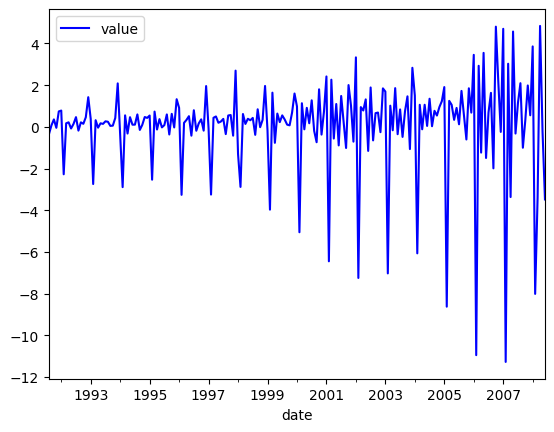

In [ ]:
#create differenced dataset
first_diff_df = drug_sales_df.diff().dropna()
first_diff_df.plot(color='blue')

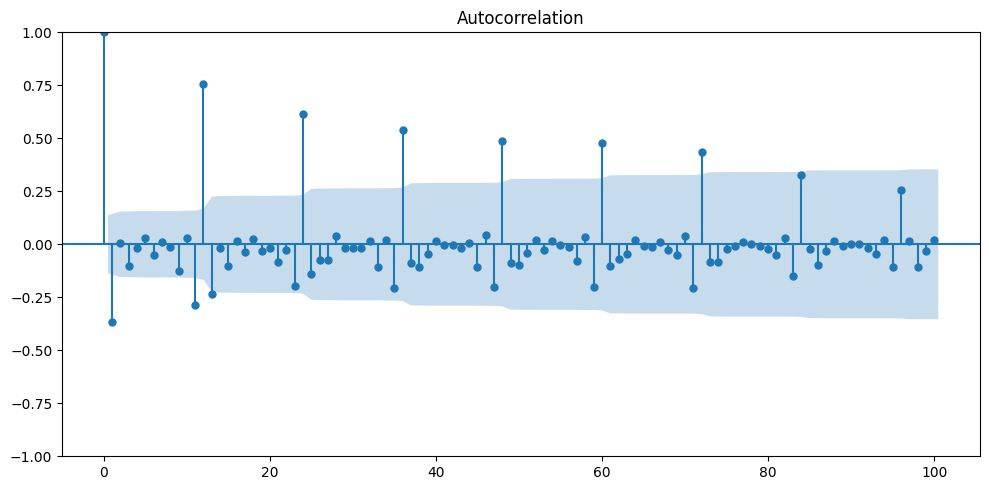

In [ ]:
# autocorrelation plot of differenced dataset
fig = plot_acf(first_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [ ]:
X = first_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.495172
p-value: 0.116653
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575


/tmp/ipykernel_4076/1110963401.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


From the ACF and line plot and the ADF test p-value we can deduce that the series is non-stationary. As we can see a seasonal pattern, let us apply seasonal differencing.

<Axes: xlabel='date'>

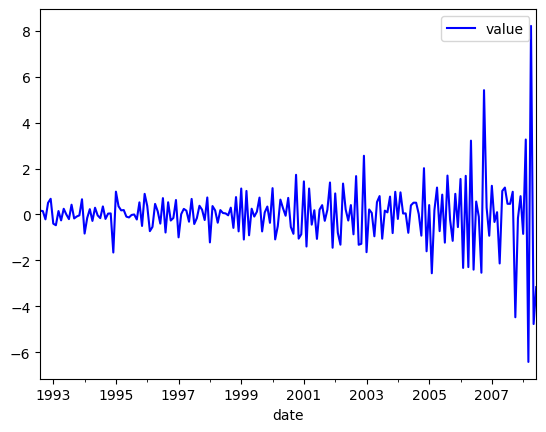

In [ ]:
seasonal_diff_df = first_diff_df.diff(12).dropna()
seasonal_diff_df.plot(color = 'blue')

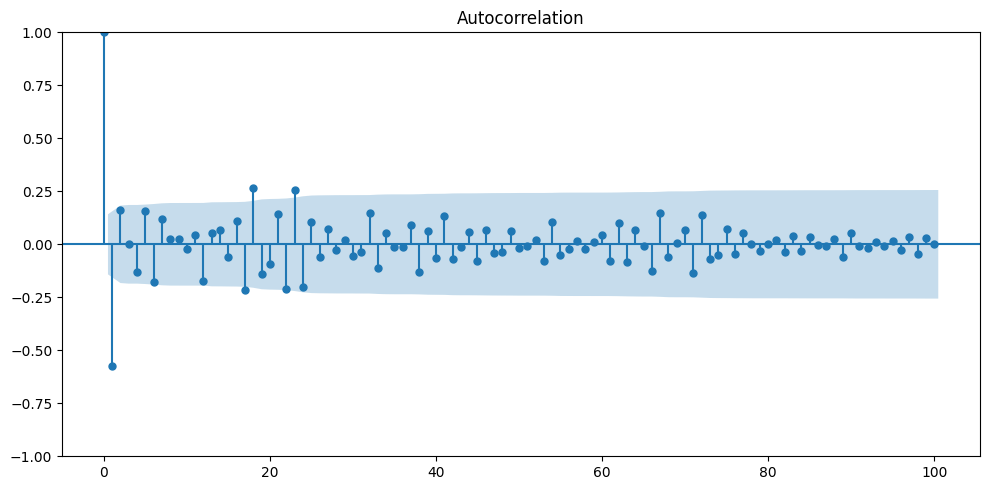

In [ ]:
# autocorrelation plot of the seasonaly differenced dataset
fig = plot_acf(seasonal_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [ ]:
X = seasonal_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.783440
p-value: 0.000058
Critical Values:
	1%: -3.468
	5%: -2.878
	10%: -2.576


/tmp/ipykernel_4076/509688674.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Since p-value is less than 0.05 we can reject the null hypothesis and the data is stationary.

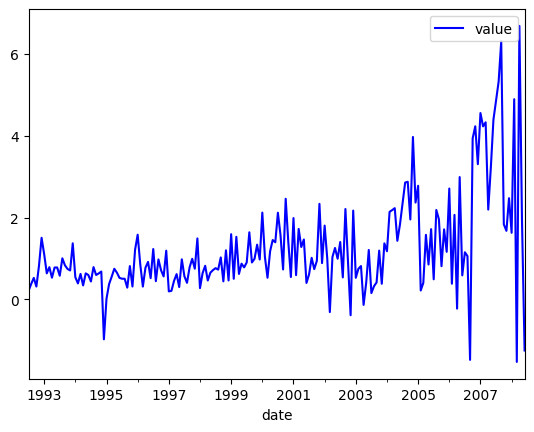

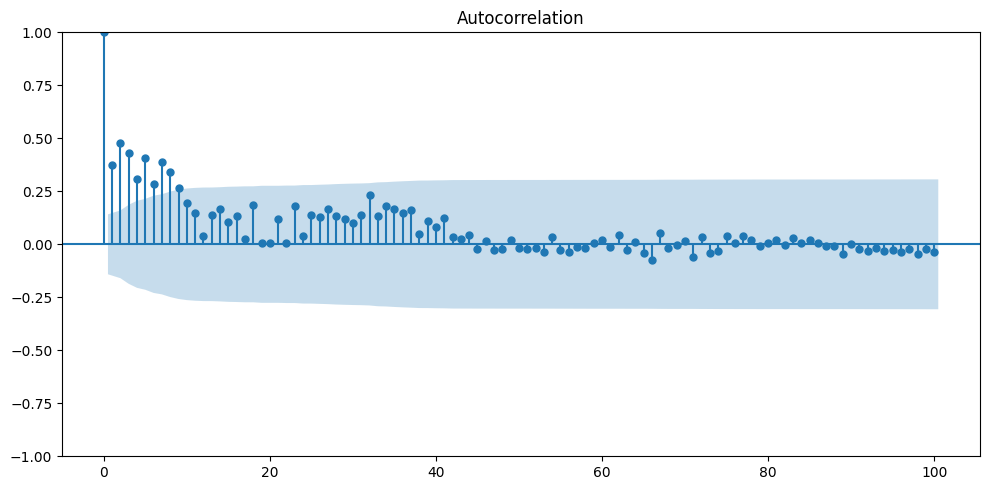

ADF Statistic: -2.092723
p-value: 0.247451
Critical Values:
	1%: -3.468
	5%: -2.878
	10%: -2.576


/tmp/ipykernel_4076/1989188713.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


In [ ]:
seasnl_diff_df = drug_sales_df.diff(12).dropna()
seasnl_diff_df.plot(color='blue')

fig = plot_acf(seasnl_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

X = seasnl_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

## Seasonal differencing and interpretation of differencing

When both seasonal and first differences are applied -
1. it makes no difference which is done first—the result will be the same.
2. If seasonality is strong, it is recommended that seasonal differencing be done first because sometimes the resulting series will be stationary and there will be no need for further first difference.

Also, it is important that if differencing is used, the differences are interpretable.
1. first differences are the change between one observation and the next.
2. seasonal differences are the change between one year to the next.

But taking lag 3 differences for yearly data, for example, results in a model which cannot be sensibly interpreted.


## Time to test out the forecasts - split data into train and test sets

In [ ]:
drug_sales_df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(drug_sales_df, test_size=12, random_state=25, shuffle = False)
#shuffle = False is very important to ensure the order of the data

print(f"No. of training examples: {train_data.shape[0]}")
print(f"No. of testing examples: {test_data.shape[0]}")

No. of training examples: 192
No. of testing examples: 12


In [ ]:
train_data

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2007-02-01,16.763869
2007-03-01,19.792754
2007-04-01,16.427305


In [ ]:
test_data

,value
date,
2007-07-01,21.834890
2007-08-01,23.930204
2007-09-01,22.930357
2007-10-01,23.263340
2007-11-01,25.250030
2007-12-01,25.806090
2008-01-01,29.665356
2008-02-01,21.654285
2008-03-01,18.264945


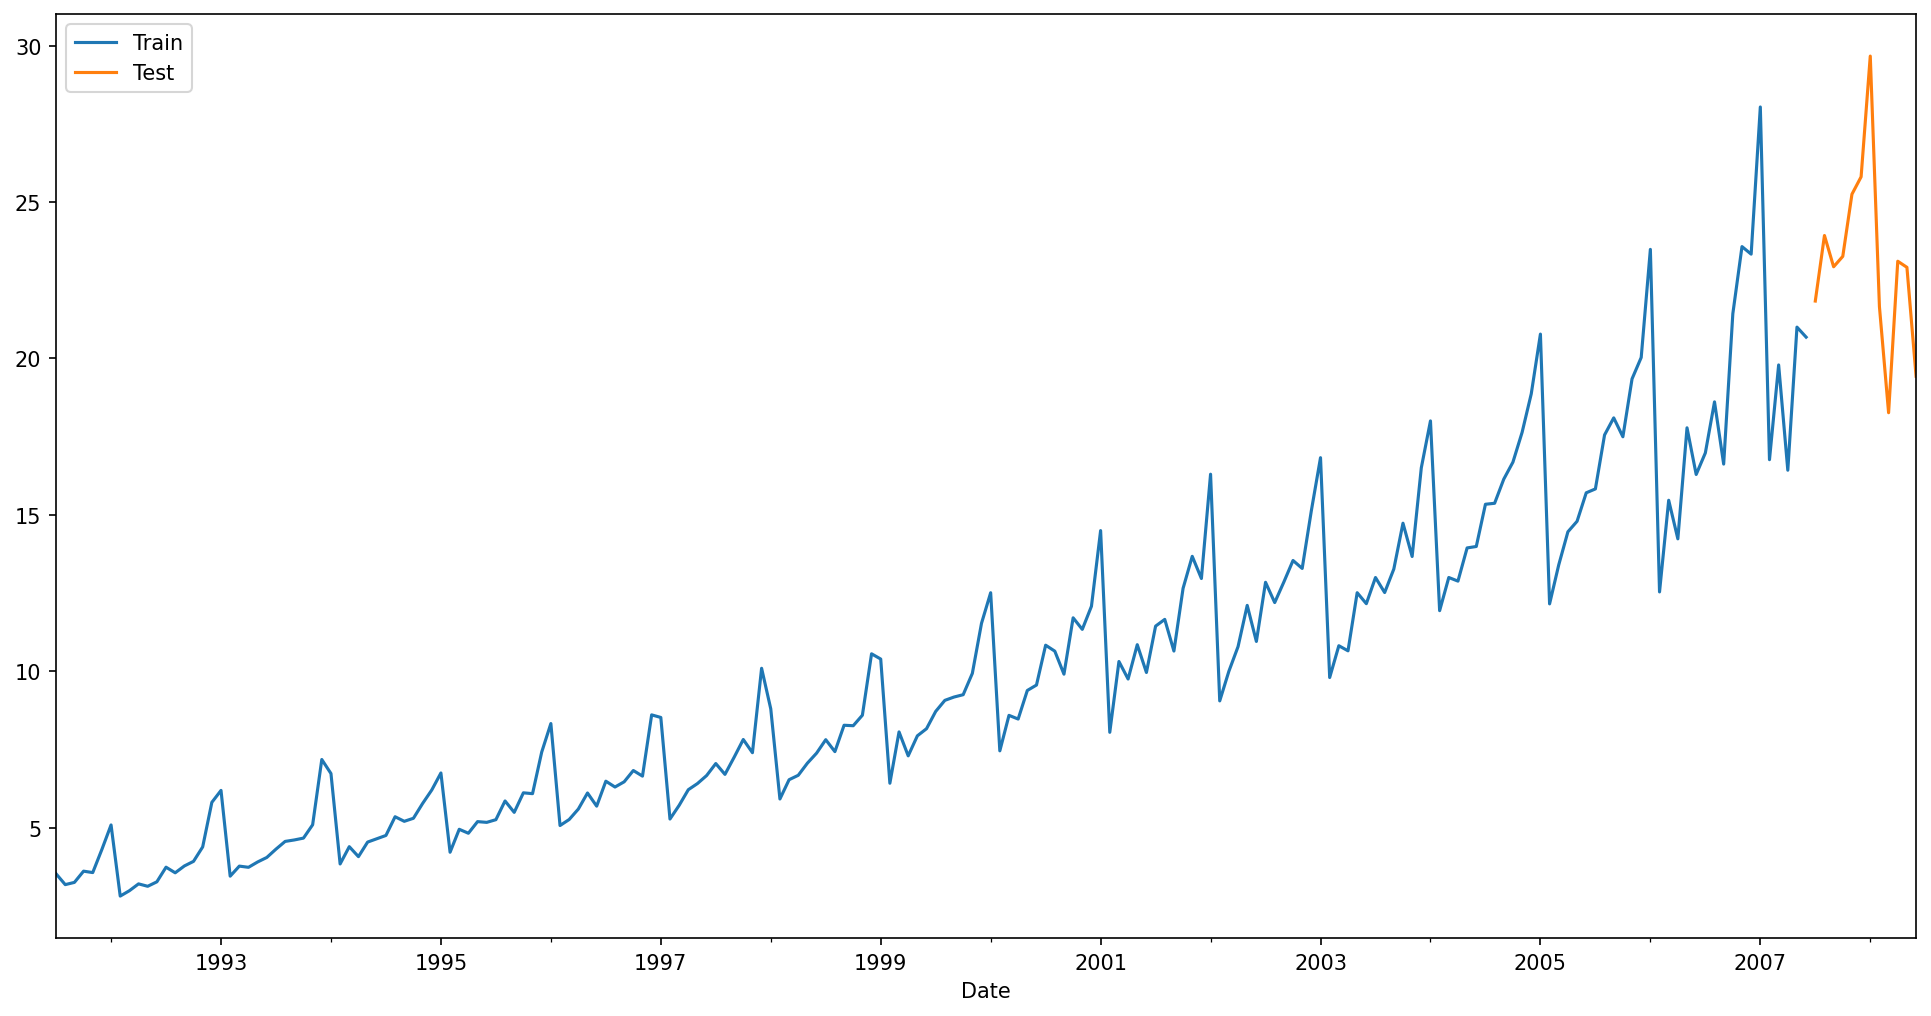

In [ ]:
#Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
train_data['value'].plot(label='Train')
test_data['value'].plot(label='Test')

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


## Fitting Models - AR, MA, non-seasonal, and seasonal ARIMA Models

ARIMA models cater to a suite of standard structures in time series data, and as such provide a simple yet powerful method for making skillful time series forecasts.

ARIMA is an acronym that stands for AutoRegressive Integrated Moving Average.

1. AR: Autoregression. A model that uses the dependent relationship between an observation and some number of lagged observations.
2. I: Integrated. The use of differencing of raw observations (e.g. subtracting an observation from an observation at the previous time step) in order to make the time series stationary.
3. MA: Moving Average. A model that uses the dependency between an observation and a residual error from a moving average model applied to lagged observations.

Each of these components are explicitly specified in the model as a parameter. A standard notation is used of ARIMA(p,d,q) where the parameters are substituted with integer values to quickly indicate the specific ARIMA model being used.

The parameters of the ARIMA model are defined as follows:

p: The number of lag observations included in the model, also called the lag order.
d: The number of times that the raw observations are differenced, also called the degree of differencing.
q: The size of the moving average window, also called the order of moving average.

A linear regression model is constructed including the specified number and type of terms, and the data is prepared by a degree of differencing in order to make it stationary, i.e. to remove trend and seasonal structures that negatively affect the regression model.

A value of 0 can be used for a parameter, which indicates to not use that element of the model. This way, the ARIMA model can be configured to perform the function of an ARMA model, and even a simple AR, I, or MA model.

Source:
1. https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

### How to find the order of the AR (p) and MA (q) term?

You can find out the required number of AR and MA terms by inspecting the Autocorrelation (ACF) and Partial Autocorrelation (PACF) plot of the differenced time series.

What is Partial Autocorrelation?

Recall that an ACF plot shows the autocorrelations which measure the relationship between lagged values of a time series. Now if yt and yt−1 are correlated, then yt−1 and yt-2 must also be correlated. However, then yt and yt-2 might be correlated, simply because they are both connected to yt-1, rather than because of any new information contained in yt-2 that could be used in forecasting yt.

To overcome this problem, we can use partial autocorrelations. These measure the relationship between yt and  yt-k after removing the effects of lags 1,2,3,...,k-1.

Key Concepts:
-------------
1. ACF (Autocorrelation Function) measures both direct and indirect relationships between current and lagged values.
2. PACF (Partial Autocorrelation Function) measures only the *direct* relationship between the current value and a specific lag, removing the influence of intermediate lags.

How to use them:
----------------
- ACF helps identify MA(q) components:
    - Sharp cutoff after lag q → suggests MA(q)
    - Gradual decay → AR component may be present

- PACF helps identify AR(p) components:
    - Sharp cutoff after lag p → suggests AR(p)
    - Gradual decay → MA component may be present

Note:
- These plots are useful only after the time series has been made stationary (e.g., via differencing).
- For ARMA (mixed) models, both ACF and PACF may show gradual decay.

**SUMMARY**

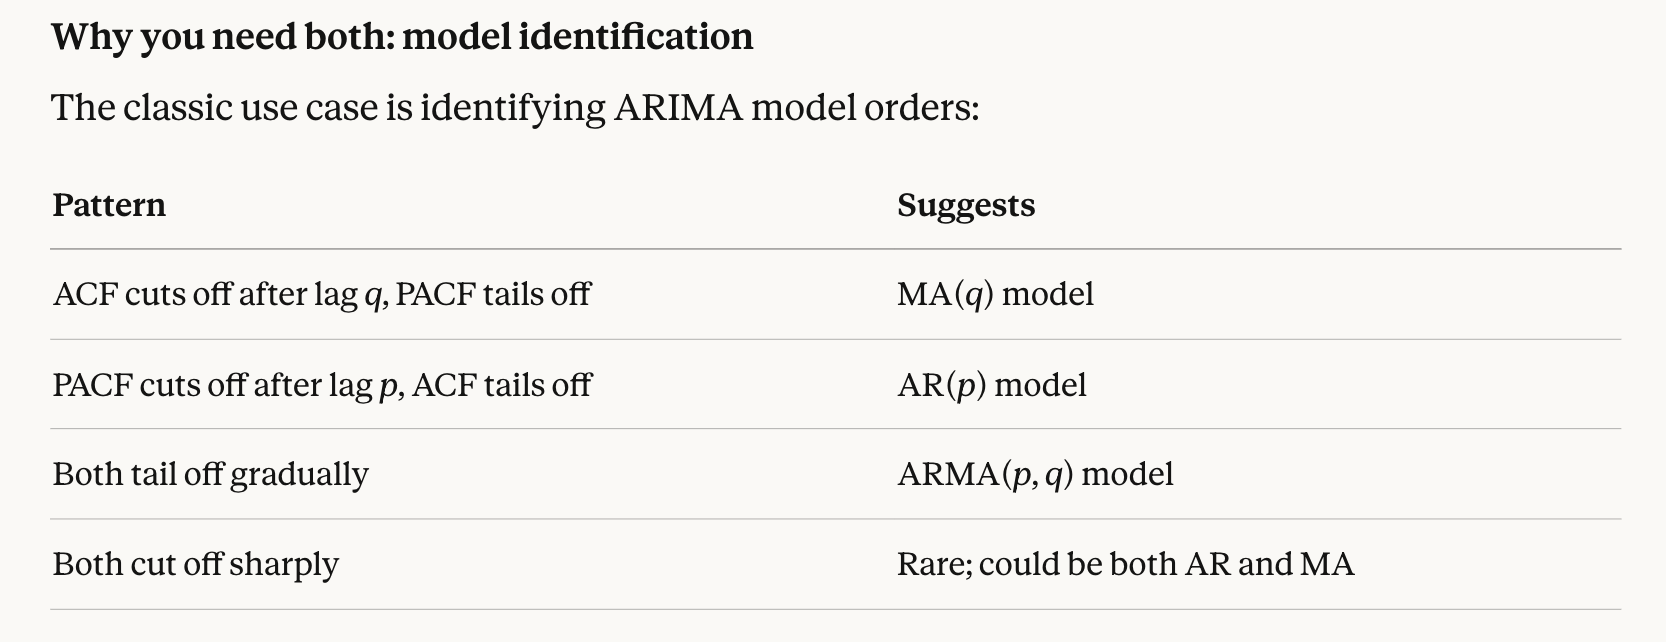

In [ ]:
# AR or MA?

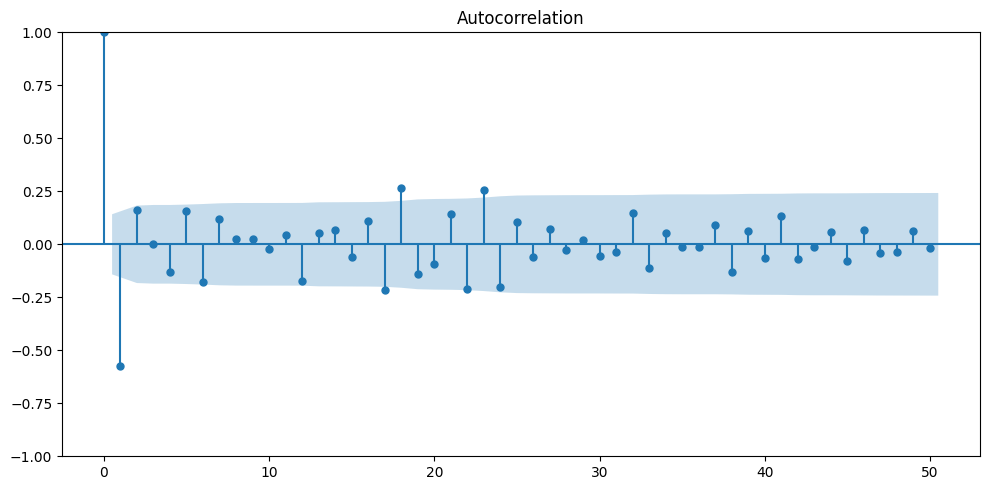

In [ ]:
# autocorrelation plot of the seasonaly differenced dataset
fig = plot_acf(seasonal_diff_df, lags=50)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

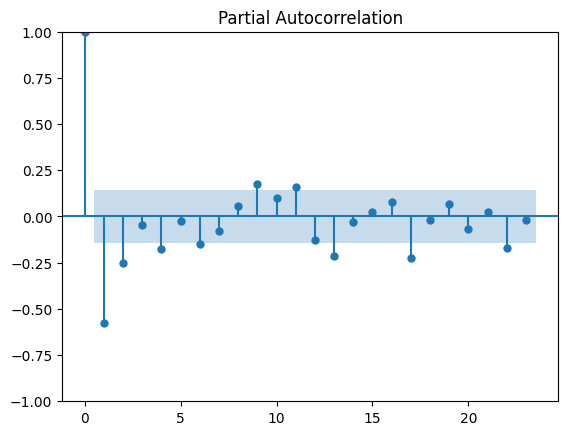

In [ ]:
#plot PACF of the differenced time series.
plot_pacf(seasonal_diff_df)
plt.show()

In [ ]:
# AR or MA? p=2, d=1, q=1

### Build ARIMA manually

In [ ]:
# p,d,q = 2,1,1 ARIMA Model
manual_model = sm.tsa.ARIMA(train_data, order=(2,1,1))
manual_model_fit = manual_model.fit()
print(manual_model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros 

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  192
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -388.544
Date:                Fri, 18 Sep 2026   AIC                            785.088
Time:                        03:53:14   BIC                            798.097
Sample:                    07-01-1991   HQIC                           790.358
                         - 06-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2753      0.126      2.191      0.028       0.029       0.522
ar.L2          0.0996      0.103      0.966      0.334      -0.102       0.302
ma.L1         -0.8552      0.078    -11.024      0.0

| Test / Metric              | Result                          | What It Means                                                                                                | Interpretation                                                                                                    | How to Address (if needed)                                                                                                                                                             |
| -------------------------- | ------------------------------- | ------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Ljung-Box (Q)**          | Q = 0.18, Prob(Q) = 0.67        | Tests whether residuals are autocorrelated. Null hypothesis: residuals are white noise.                      | ✅ **Residuals are not autocorrelated.** The model successfully captured most time dependence.                     | No action needed — model’s temporal structure is adequate.                                                                                                                             |
| **Jarque–Bera (JB)**       | JB = 174.05, p = 0.00           | Tests if residuals are normally distributed (based on skewness and kurtosis).                                | ❌ **Residuals are not normal.** Likely presence of outliers or heavy tails.                                       | • Apply a log or Box–Cox transformation if data are positive.<br>• Use robust standard errors.<br>• Consider models tolerant to non-normal errors (e.g., SARIMAX with t-distribution). |
| **Heteroskedasticity (H)** | H = 9.47, p = 0.00              | Tests whether residual variance is constant over time.                                                       | ❌ **Variance changes over time** (volatility clustering).                                                         | • Try modeling conditional variance using **ARCH/GARCH** family models.<br>• Apply variance-stabilizing transformations (log, sqrt).                                                   |
| **Skew / Kurtosis**        | Skew = -0.83<br>Kurtosis = 7.37 | Skew measures asymmetry; kurtosis measures tail heaviness. Normal ≈ 0 skew, 3 kurtosis.                      | ❌ **Negative skew** (longer left tail) and **high kurtosis** (sharp peak, heavy tails).                           | • Outlier trimming or winsorizing.<br>• Try data transformations (log, cube root).<br>• Consider using Student-t innovations in the ARIMA model.                                       |
| **σ² (sigma²)**            | 3.4110 (SE = 0.247)             | The **variance of the model’s residuals (errors)** — how much unexplained variability remains after fitting. | This is the estimated “noise” level. A smaller σ² indicates a tighter fit (lower average squared forecast error). | Used mainly to compare models — prefer models with smaller σ² (holding everything else constant).                                                                                      |


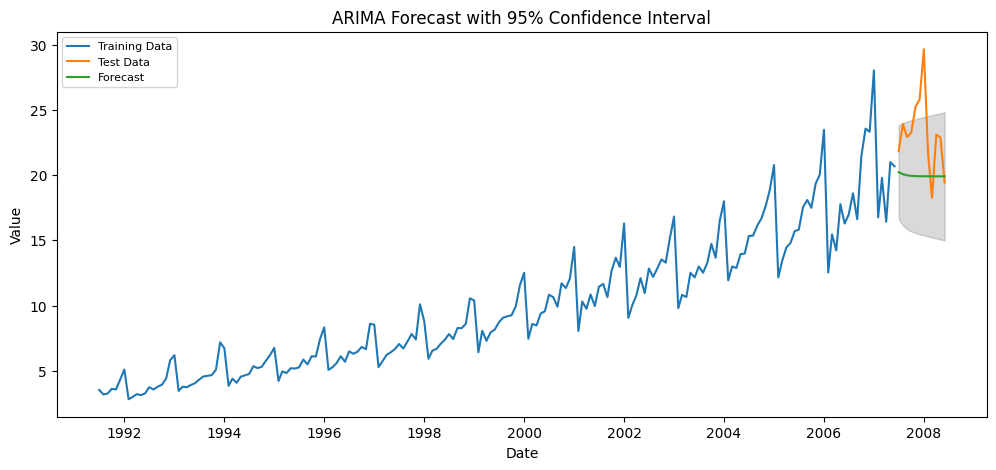

In [ ]:
# Forecast
forecast_steps = 12
forecast_values = manual_model_fit.forecast(steps=forecast_steps)

# Calculate the standard errors of the forecasts
stderr = manual_model_fit.get_prediction(start=len(train_data), end=len(train_data) + forecast_steps - 1).se_mean

# Calculate lower and upper bounds for a 95% confidence interval
alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series = pd.Series(forecast_values, index=test_data.index)
lower_series = pd.Series(lower_bound, index=test_data.index)
upper_series = pd.Series(upper_bound, index=test_data.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data, label='Training Data')
plt.plot(test_data, label='Test Data')
plt.plot(fc_series, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('ARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

## Auto ARIMA - Non seasonal

auto_arima() uses a stepwise approach to search multiple combinations of p,d,q parameters and chooses the best model that has the least AIC.

In [ ]:
non_seasonal_auto_model = pm.auto_arima(train_data, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd'
                          max_p=3, max_q=3, # maximum p and q
                          m=12,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

print(non_seasonal_auto_model.summary())

/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1473.879, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=844.283, Time=0.25 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1279.130, Time=0.64 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.42 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=802.660, Time=0.32 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=794.855, Time=1.05 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=795.190, Time=1.19 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=799.333, Time=1.82 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=797.769, Time=0.75 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.63 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=785.896, Time=2.20 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=792.088, Time=5.19 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=788.158, Time=2.41 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=788.802, Time=1.63 sec

Best model:  ARIMA(3,0,2)(0,0,0)[0]          
Total 

In [ ]:
# Forecast
n_periods = 12
fc_auto_nonseasonal, confint = non_seasonal_auto_model.predict(n_periods=n_periods, return_conf_int=True)

In [ ]:
fc_auto_nonseasonal

,0
2007-07-01,21.107313
2007-08-01,19.519578
2007-09-01,20.670852
2007-10-01,19.354501
2007-11-01,20.595253
2007-12-01,19.320097
2008-01-01,20.567009
2008-02-01,19.302831
2008-03-01,20.545005
2008-04-01,19.287813


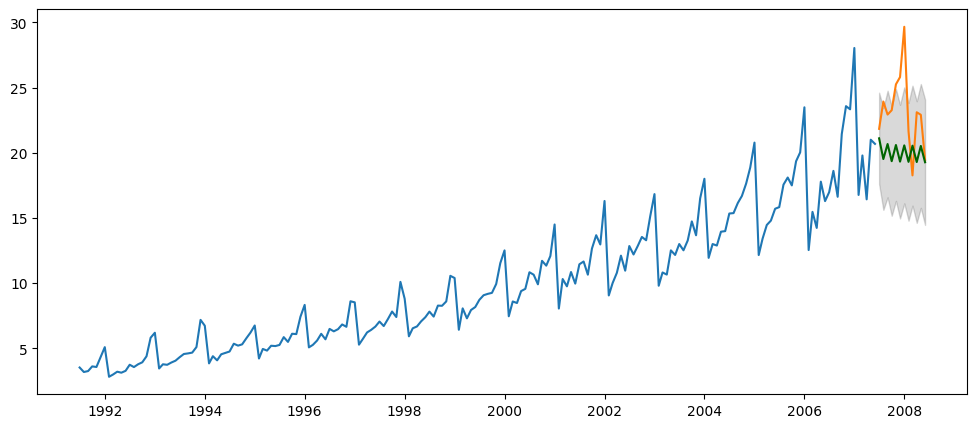

In [ ]:
# make series for plotting purpose
fc_series_auto_nonseasonal = pd.Series(fc_auto_nonseasonal, index=test_data.index)
lower_series = pd.Series(confint[:, 0], index=test_data.index)
upper_series = pd.Series(confint[:, 1], index=test_data.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='train')
plt.plot(test_data, label='test')
plt.plot(fc_series_auto_nonseasonal, color='darkgreen', label='forecast')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)

plt.show()

## Auto ARIMA Seasonal

In [ ]:
# Seasonal - fit stepwise auto-ARIMA
smodel = pm.auto_arima(train_data, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=422.169, Time=0.47 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=505.309, Time=0.12 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=440.957, Time=0.43 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=422.766, Time=0.55 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=423.219, Time=0.33 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=423.200, Time=1.29 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=421.304, Time=2.57 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=420.235, Time=6.56 sec
 ARIMA(1,1,1)(2,1,2)[12]             : AIC=422.207, Time=2.52 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=420.588, Time=1.51 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=420.770, Time=1.35 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=435.856, Time=1.21 sec
 ARIMA(2,1,1)(1,1,2)[12]             : AIC=420.069, Time=4.47 sec
 ARIMA(2,1,1)(0,1,2)[12]             : AIC=420.743, Time=3.01 sec
 ARIMA(2,1,1)(1,1,1)[12]         

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  192
Model:             SARIMAX(3, 1, 2)x(1, 1, 2, 12)   Log Likelihood                -199.854
Date:                            Fri, 18 Sep 2026   AIC                            417.708
Time:                                    03:55:16   BIC                            446.395
Sample:                                07-01-1991   HQIC                           429.341
                                     - 06-01-2007                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5685      0.199     -2.853      0.004      -0.959      -0.178
ar.L2          0.3585      0.130      2.760      0.006       0.104       0.613
ar.L3          0.3405      0.077      4.416      0.000       0.189       0.492
ma.L1         -0.2247      0.231     -0.974      0.330      -0.677       0.227
ma.L2         -0.6161      0.171     -3.609      0.000      -0.951      -0.282
ar.S.L12      -0.5863      0.357     -1.643      0.100      -1.286       0.113
ma.S.L12       0.4531      0.353      1.284      0.199      -0.239       1.145
ma.S.L24      -0.2938      0.103     -2.852      0.004      -0.496      -0.092
sigma2         0.5347      0.042     12.711      0.000       0.452       0.617
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               161.12
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               8.91   Skew:                             0.57
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Forecast
n_periods = 12
fc_auto_seasonal, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)

In [ ]:
fc_auto_seasonal

,0
2007-07-01,20.320223
2007-08-01,22.168218
2007-09-01,20.120739
2007-10-01,24.362062
2007-11-01,26.282240
2007-12-01,26.090024
2008-01-01,30.348502
2008-02-01,19.278899
2008-03-01,22.159230
2008-04-01,19.445153


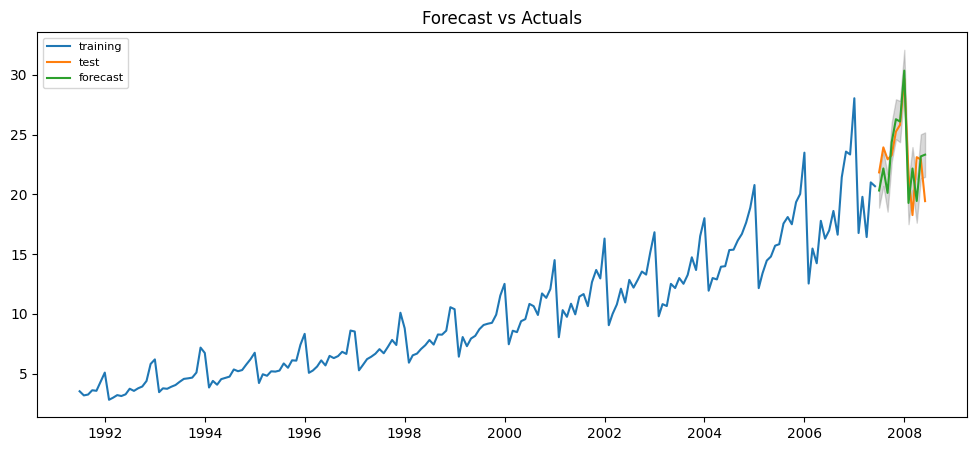

In [ ]:
# make series for plotting purpose
fc_series_auto_seasonal = pd.Series(fc_auto_seasonal, index=test_data.index)
lower_series = pd.Series(confint[:, 0], index=test_data.index)
upper_series = pd.Series(confint[:, 1], index=test_data.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='training')
plt.plot(test_data, label='test')
plt.plot(fc_series_auto_seasonal, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

### Model Evaluation

In [ ]:
#define metrics dataframe which will be used below for storing results
metrics_dataframe = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'MAPE'])

def metrics_cal(actuals, predictions, model):
    mse = mean_squared_error(actuals, predictions)
    rmse = sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    df = pd.DataFrame({'Model': [model],
                       'RMSE': [rmse],
                       'MAE': [mae],
                       'MAPE': [mape]})

    global metrics_dataframe
    metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)
    return metrics_dataframe

In [ ]:
fc_series

,predicted_mean
date,
2007-07-01,20.233472
2007-08-01,20.078415
2007-09-01,19.991156
2007-10-01,19.951690
2007-11-01,19.932134
2007-12-01,19.922819
2008-01-01,19.918307
2008-02-01,19.916137
2008-03-01,19.915090


In [ ]:
#get all the metrics
metrics_dataframe = metrics_cal(test_data.values.flatten(),
                                fc_series.values.flatten(),
                                'Manual ARIMA')

metrics_dataframe = metrics_cal(test_data.values.flatten(),
                                fc_series_auto_nonseasonal.values.flatten(),
                                'Auto ARIMA Non Seasonal')

metrics_dataframe = metrics_cal(test_data.values.flatten(),
                                fc_series_auto_seasonal.values.flatten(),
                                'Auto ARIMA Seasonal')



/tmp/ipykernel_4076/2243136297.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)


In [ ]:
metrics_dataframe.sort_values(by='MAE')

,Model,RMSE,MAE,MAPE
2,Auto ARIMA Seasonal,2.336624,1.939027,9.005583
1,Auto ARIMA Non Seasonal,4.261578,3.545363,14.481051
0,Manual ARIMA,4.282390,3.559526,14.470590


In [ ]:
# Create a data frame with all the predictions along with the test data
test_pred_df = test_data.copy()

# Add all predictions
test_pred_df = test_pred_df.assign(manual_arima_pred = fc_series.values.flatten(),
                                   auto_nonseasonal_pred = fc_series_auto_nonseasonal.values.flatten(),
                                   auto_seasonal_pred = fc_series_auto_seasonal.values.flatten(),
                                   avg_pred = (fc_series.values.flatten()+
                                               fc_series_auto_nonseasonal.values.flatten()+
                                               fc_series_auto_seasonal.values.flatten())/3)

test_pred_df

,value,manual_arima_pred,auto_nonseasonal_pred,auto_seasonal_pred,avg_pred
date,,,,,
2007-07-01,21.834890,20.233472,21.107313,20.320223,20.553669
2007-08-01,23.930204,20.078415,19.519578,22.168218,20.588737
2007-09-01,22.930357,19.991156,20.670852,20.120739,20.260916
2007-10-01,23.263340,19.951690,19.354501,24.362062,21.222751
2007-11-01,25.250030,19.932134,20.595253,26.282240,22.269875
2007-12-01,25.806090,19.922819,19.320097,26.090024,21.777647
2008-01-01,29.665356,19.918307,20.567009,30.348502,23.611273
2008-02-01,21.654285,19.916137,19.302831,19.278899,19.499289
2008-03-01,18.264945,19.915090,20.545005,22.159230,20.873108


In [ ]:
metrics_dataframe = metrics_cal(test_data.values.flatten(),
                                test_pred_df['avg_pred'],
                                'Average')


In [ ]:
metrics_dataframe.sort_values(by='MAE')

,Model,RMSE,MAE,MAPE
2,Auto ARIMA Seasonal,2.336624,1.939027,9.005583
3,Average,3.093732,2.819031,11.864414
1,Auto ARIMA Non Seasonal,4.261578,3.545363,14.481051
0,Manual ARIMA,4.282390,3.559526,14.470590


## Time Series Cross Validation - see slides

Sources:

https://medium.com/@soumyachess1496/cross-validation-in-time-series-566ae4981ce4


---
# Assignment 2 — Backtesting ETS and ARIMA models

**Problem definition.** Predict monthly anti-diabetic drug sales in Australia, and back test 12-month forecasts over four test periods: July 2004–June 2005, July 2005–June 2006, July 2006–June 2007, July 2007–June 2008.

**Method.** For each test period, every model is re-fitted on data ending the month *before* that period begins. No model ever sees the window it is asked to forecast. This is why standard k-fold cross validation cannot be used on time series: shuffled folds let the model train on future observations (data leakage).

**Models compared.** ETS Simple, ETS Double, ETS Triple (Holt-Winters), Manual ARIMA(2,1,1), Auto ARIMA (non-seasonal), Auto SARIMA (seasonal), and the average of all six.

The work is built up one step at a time: first a single test period, then the same steps wrapped into a function and applied to all four.

### Step 0 — Define the four test periods and the MAPE helper

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pmdarima as pm

test_windows = [('2004-07-01', '2005-06-01'),
                ('2005-07-01', '2006-06-01'),
                ('2006-07-01', '2007-06-01'),
                ('2007-07-01', '2008-06-01')]

def mape(actual, forecast):
    actual, forecast = np.asarray(actual, float), np.asarray(forecast, float)
    return np.mean(np.abs((actual - forecast) / actual)) * 100

### Step 1 — Split one test period first

Start with the earliest window so the logic can be checked before it is repeated.
`train` must stop one month before the test period starts.

In [ ]:
start, end = test_windows[0]

test  = drug_sales_df.loc[start:end, 'value']         # the 12 months to forecast
train = drug_sales_df.loc[:start, 'value'].iloc[:-1]  # everything strictly before that

print('train:', len(train), 'rows, ends', train.index[-1].strftime('%Y-%m'))
print('test :', len(test), 'rows,', test.index[0].strftime('%Y-%m'),
      '~', test.index[-1].strftime('%Y-%m'))

train: 156 rows, ends 2004-06
test : 12 rows, 2004-07 ~ 2005-06


### Step 2 — Fit the ETS models on this training set

Simple captures the level only, Double adds a trend, Triple adds a 12-month seasonal cycle.
Triple is fitted twice — once with additive seasonality and once with multiplicative — because
the size of the yearly peaks appears to grow with the level of the series. The backtest results
will show which assumption holds.

In [ ]:
ets_simple = SimpleExpSmoothing(
    train, initialization_method='estimated').fit().forecast(12)

ets_double = ExponentialSmoothing(
    train, trend='add', initialization_method='estimated').fit().forecast(12)

# Triple ETS fitted twice: additive vs multiplicative seasonality.
# Additive assumes the seasonal swing is a fixed amount; multiplicative assumes it is a
# fixed percentage of the level. Comparing both lets the data decide.
ets_triple_add = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12,
    initialization_method='estimated').fit().forecast(12)

ets_triple_mul = ExponentialSmoothing(
    train, trend='add', seasonal='mul', seasonal_periods=12,
    initialization_method='estimated').fit().forecast(12)

pd.DataFrame({'Triple additive': ets_triple_add, 'Triple multiplicative': ets_triple_mul})

,Triple additive,Triple multiplicative
2004-07-01,14.656414,14.846219
2004-08-01,14.259356,14.627324
2004-09-01,14.961021,14.759968
2004-10-01,16.299623,16.091809
2004-11-01,15.496983,16.084906
2004-12-01,18.007880,18.486182
2005-01-01,19.552889,20.288920
2005-02-01,13.209538,12.100711
2005-03-01,14.170737,13.716624
2005-04-01,14.012359,13.645985


### Step 3 — Fit the three ARIMA models on the same training set

Same parameters used earlier in the notebook, only the training data has changed.

In [ ]:
arima_manual = sm.tsa.ARIMA(train, order=(2, 1, 1)).fit().forecast(steps=12)

model_ns = pm.auto_arima(train, start_p=0, start_q=0, test='adf',
                         max_p=3, max_q=3, d=None, seasonal=False,
                         error_action='ignore', suppress_warnings=True, stepwise=True)
arima_auto_ns = model_ns.predict(n_periods=12)

model_s = pm.auto_arima(train, start_p=1, start_q=1, test='adf',
                        max_p=3, max_q=3, m=12, start_P=0, seasonal=True,
                        d=None, D=1, error_action='ignore',
                        suppress_warnings=True, stepwise=True)
arima_auto_s = model_s.predict(n_periods=12)

arima_auto_s

,0
2004-07-01,14.511729
2004-08-01,14.178498
2004-09-01,14.609972
2004-10-01,16.099156
2004-11-01,15.424344
2004-12-01,17.652314
2005-01-01,19.364367
2005-02-01,13.253874
2005-03-01,14.329019
2005-04-01,14.331793


### Step 4 — Collect the seven forecasts and score them

The ensemble is the simple average of the seven forecasts.

In [ ]:
forecasts = {'ETS Simple': ets_simple,
             'ETS Double': ets_double,
             'ETS Triple (additive)': ets_triple_add,
             'ETS Triple (multiplicative)': ets_triple_mul,
             'Manual ARIMA(2,1,1)': arima_manual,
             'Auto ARIMA (non-seasonal)': arima_auto_ns,
             'Auto SARIMA (seasonal)': arima_auto_s}

# put every forecast on the test index so they can be compared
forecasts = {name: pd.Series(np.asarray(values, float), index=test.index)
             for name, values in forecasts.items()}

forecasts['Ensemble Average'] = sum(forecasts.values()) / len(forecasts)

In [ ]:
one_window = pd.DataFrame(
    {'Model': list(forecasts),
     'RMSE': [sqrt(mean_squared_error(test, p)) for p in forecasts.values()],
     'MAE' : [mean_absolute_error(test, p)      for p in forecasts.values()],
     'MAPE': [mape(test, p)                     for p in forecasts.values()],
     # Mean Error keeps its sign, so it shows bias: positive = the model
     # under-forecast on average, negative = it over-forecast.
     'Mean Error': [(test - p).mean()           for p in forecasts.values()]})

one_window.sort_values('RMSE').round(2)

,Model,RMSE,MAE,MAPE,Mean Error
3,ETS Triple (multiplicative),0.80,0.67,4.16,0.58
2,ETS Triple (additive),1.04,0.93,5.84,0.56
6,Auto SARIMA (seasonal),1.15,1.01,6.31,0.58
7,Ensemble Average,2.04,1.67,9.91,1.33
1,ETS Double,2.53,2.00,12.09,0.97
0,ETS Simple,3.10,2.48,14.47,2.13
4,"Manual ARIMA(2,1,1)",3.14,2.52,14.68,2.19
5,Auto ARIMA (non-seasonal),3.19,2.56,14.94,2.27


### Step 5 — Wrap Steps 1–4 into a function

Identical code to the cells above, with `start` and `end` as inputs so it can be reused for
each test period. It returns the actuals and all forecasts for one window.

In [ ]:
def forecast_one_window(start, end):
    test  = drug_sales_df.loc[start:end, 'value']
    train = drug_sales_df.loc[:start, 'value'].iloc[:-1]

    fc = {}
    fc['ETS Simple'] = SimpleExpSmoothing(
        train, initialization_method='estimated').fit().forecast(12)
    fc['ETS Double'] = ExponentialSmoothing(
        train, trend='add', initialization_method='estimated').fit().forecast(12)
    fc['ETS Triple (additive)'] = ExponentialSmoothing(
        train, trend='add', seasonal='add', seasonal_periods=12,
        initialization_method='estimated').fit().forecast(12)
    fc['ETS Triple (multiplicative)'] = ExponentialSmoothing(
        train, trend='add', seasonal='mul', seasonal_periods=12,
        initialization_method='estimated').fit().forecast(12)

    fc['Manual ARIMA(2,1,1)'] = sm.tsa.ARIMA(train, order=(2, 1, 1)).fit().forecast(steps=12)

    m_ns = pm.auto_arima(train, start_p=0, start_q=0, test='adf',
                         max_p=3, max_q=3, d=None, seasonal=False,
                         error_action='ignore', suppress_warnings=True, stepwise=True)
    fc['Auto ARIMA (non-seasonal)'] = m_ns.predict(n_periods=12)

    m_s = pm.auto_arima(train, start_p=1, start_q=1, test='adf',
                        max_p=3, max_q=3, m=12, start_P=0, seasonal=True,
                        d=None, D=1, error_action='ignore',
                        suppress_warnings=True, stepwise=True)
    fc['Auto SARIMA (seasonal)'] = m_s.predict(n_periods=12)

    fc = {name: pd.Series(np.asarray(values, float), index=test.index)
          for name, values in fc.items()}
    fc['Ensemble Average'] = sum(fc.values()) / len(fc)

    print(f"  train {len(train)} rows (ends {train.index[-1]:%Y-%m}) -> test {len(test)} rows")
    return pd.DataFrame({'Actual': test, **fc})

### Step 6 — Run the function on all four test periods

The training set grows from 156 to 192 rows, confirming each window is fitted only on
data that precedes it.

In [ ]:
backtest_preds, backtest_rows = {}, []

for start, end in test_windows:
    window = f"{pd.Timestamp(start):%Y-%m} ~ {pd.Timestamp(end):%Y-%m}"
    print(f"[{window}]")

    df = forecast_one_window(start, end)
    backtest_preds[window] = df

    for model in df.columns.drop('Actual'):
        backtest_rows.append({'Window': window, 'Model': model,
                              'RMSE': sqrt(mean_squared_error(df['Actual'], df[model])),
                              'MAE' : mean_absolute_error(df['Actual'], df[model]),
                              'MAPE': mape(df['Actual'], df[model]),
                              'Mean Error': (df['Actual'] - df[model]).mean()})

backtest_df = pd.DataFrame(backtest_rows)
print('\nresults rows:', len(backtest_df))

[2004-07 ~ 2005-06]
  train 156 rows (ends 2004-06) -> test 12 rows
[2005-07 ~ 2006-06]
  train 168 rows (ends 2005-06) -> test 12 rows
[2006-07 ~ 2007-06]
  train 180 rows (ends 2006-06) -> test 12 rows
[2007-07 ~ 2008-06]
  train 192 rows (ends 2007-06) -> test 12 rows

results rows: 32


### Step 7 — Accuracy of each model in each test period

In [ ]:
backtest_df.pivot(index='Model', columns='Window', values='RMSE').round(2)

Window,2004-07 ~ 2005-06,2005-07 ~ 2006-06,2006-07 ~ 2007-06,2007-07 ~ 2008-06
Model,,,,
Auto ARIMA (non-seasonal),3.19,3.41,4.88,4.26
Auto SARIMA (seasonal),1.15,1.15,2.62,2.34
ETS Double,2.53,2.90,3.84,3.60
ETS Simple,3.10,3.43,4.97,4.14
ETS Triple (additive),1.04,1.12,2.43,2.17
ETS Triple (multiplicative),0.80,0.98,2.34,2.02
Ensemble Average,2.04,2.21,3.54,2.58
"Manual ARIMA(2,1,1)",3.14,3.37,4.92,4.28


In [ ]:
backtest_df.pivot(index='Model', columns='Window', values='MAE').round(2)

Window,2004-07 ~ 2005-06,2005-07 ~ 2006-06,2006-07 ~ 2007-06,2007-07 ~ 2008-06
Model,,,,
Auto ARIMA (non-seasonal),2.56,2.68,3.75,3.55
Auto SARIMA (seasonal),1.01,0.99,2.34,1.94
ETS Double,2.00,2.30,2.93,2.95
ETS Simple,2.48,2.71,3.68,3.45
ETS Triple (additive),0.93,0.99,2.17,1.86
ETS Triple (multiplicative),0.67,0.88,2.05,1.64
Ensemble Average,1.67,1.74,2.83,2.39
"Manual ARIMA(2,1,1)",2.52,2.62,3.64,3.56


In [ ]:
backtest_df.pivot(index='Model', columns='Window', values='MAPE').round(2)

Window,2004-07 ~ 2005-06,2005-07 ~ 2006-06,2006-07 ~ 2007-06,2007-07 ~ 2008-06
Model,,,,
Auto ARIMA (non-seasonal),14.94,14.45,16.58,14.48
Auto SARIMA (seasonal),6.31,5.63,11.30,9.01
ETS Double,12.09,13.25,13.28,12.28
ETS Simple,14.47,14.63,16.04,14.08
ETS Triple (additive),5.84,5.67,10.46,8.54
ETS Triple (multiplicative),4.16,5.10,9.87,7.46
Ensemble Average,9.91,9.59,12.69,10.21
"Manual ARIMA(2,1,1)",14.68,14.19,15.88,14.47


### Step 8 — Overall summary

Average error across the four periods, plus average rank. Rank matters more than a single best
score: a model that is consistently near the top is the safer choice for forecasting a period no
one has seen yet.

`Mean Error` keeps its sign and therefore shows bias rather than size of error. A value near zero
means the model is not systematically high or low; a large positive value means it under-forecast
in every period, which is a different and more serious problem than random error.

In [ ]:
avg_rank = (backtest_df.assign(rank=backtest_df.groupby('Window')['RMSE'].rank())
                       .groupby('Model')['rank'].mean()
                       .rename('Avg Rank (RMSE)'))

summary = (backtest_df.groupby('Model')[['RMSE', 'MAE', 'MAPE', 'Mean Error']].mean()
                      .join(avg_rank)
                      .sort_values('Avg Rank (RMSE)')
                      .round(2))
summary

,RMSE,MAE,MAPE,Mean Error,Avg Rank (RMSE)
Model,,,,,
ETS Triple (multiplicative),1.53,1.31,6.65,0.57,1.0
ETS Triple (additive),1.69,1.49,7.63,0.61,2.0
Auto SARIMA (seasonal),1.81,1.57,8.06,0.77,3.0
Ensemble Average,2.59,2.16,10.60,1.65,4.0
ETS Double,3.22,2.55,12.73,1.36,5.0
Auto ARIMA (non-seasonal),3.94,3.13,15.11,2.77,7.0
ETS Simple,3.91,3.08,14.80,2.72,7.0
"Manual ARIMA(2,1,1)",3.93,3.08,14.81,2.74,7.0


### Step 9 — Forecasts vs actuals in all four test periods

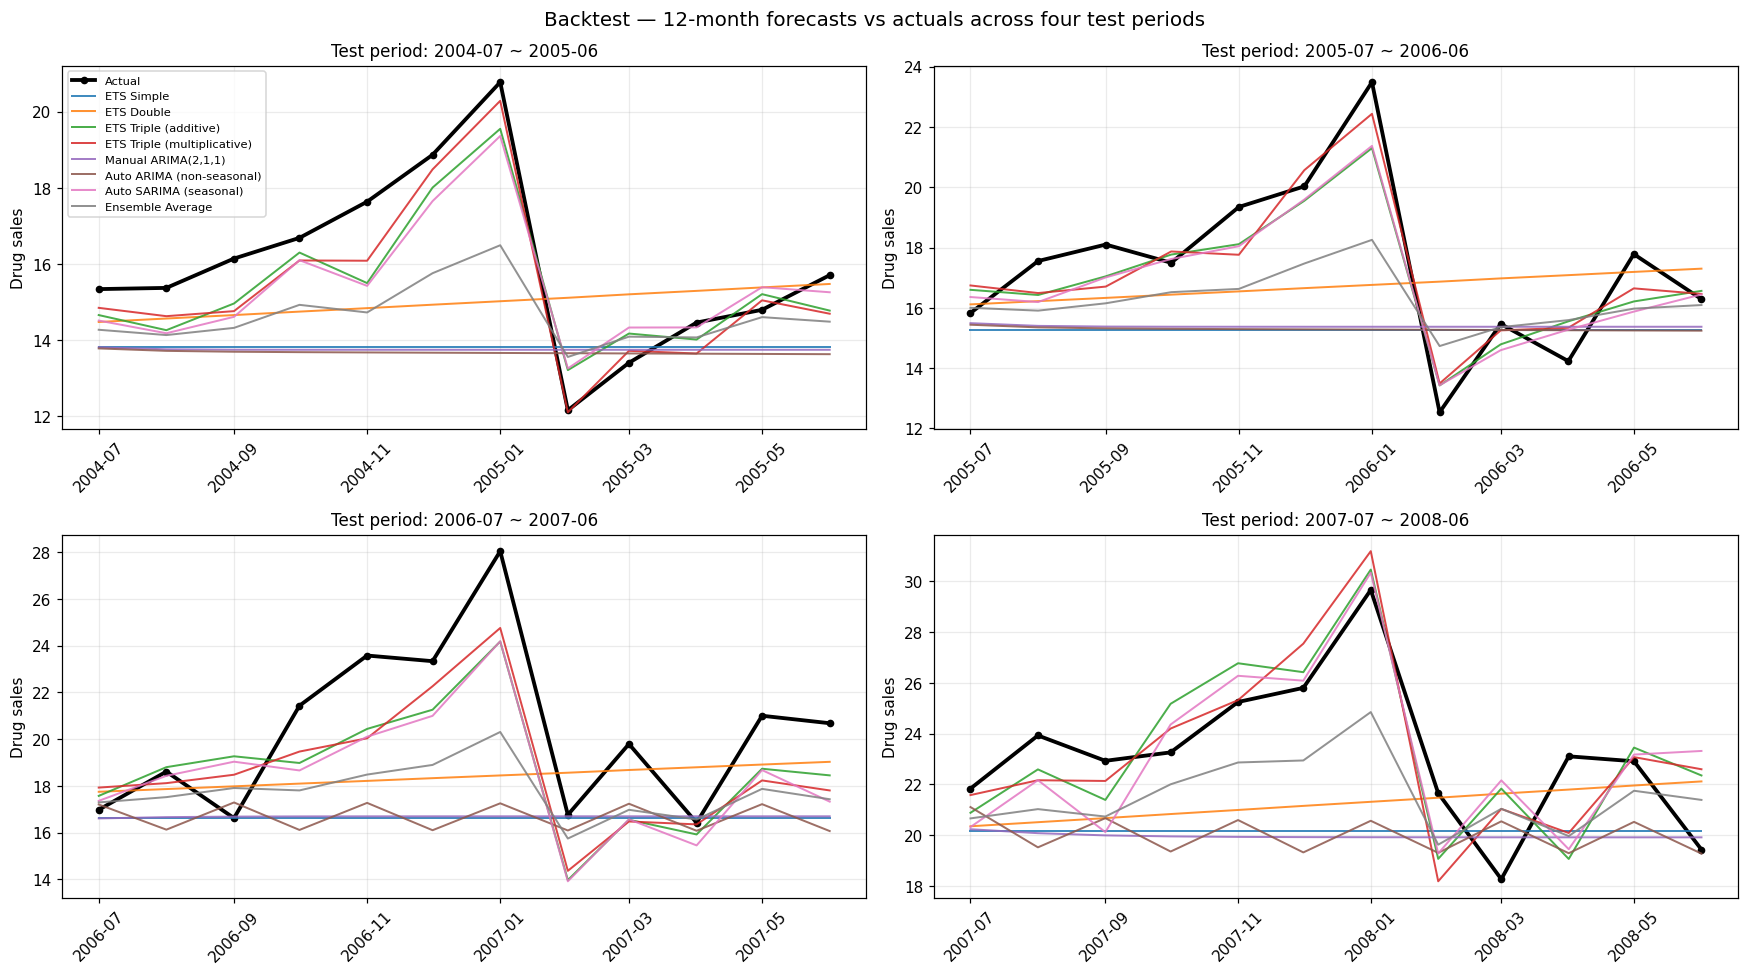

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), dpi=110)

for ax, (window, df) in zip(axes.flatten(), backtest_preds.items()):
    ax.plot(df.index, df['Actual'], color='black', marker='o', lw=2.5, ms=4, label='Actual')
    for col in df.columns.drop('Actual'):
        ax.plot(df.index, df[col], lw=1.3, alpha=0.85, label=col)
    ax.set_title(f'Test period: {window}', fontsize=11)
    ax.set_ylabel('Drug sales')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.25)

axes[0, 0].legend(fontsize=7.5, loc='upper left')
fig.suptitle('Backtest — 12-month forecasts vs actuals across four test periods', fontsize=13)
fig.tight_layout()
plt.show()

### Step 10 — Average error per model

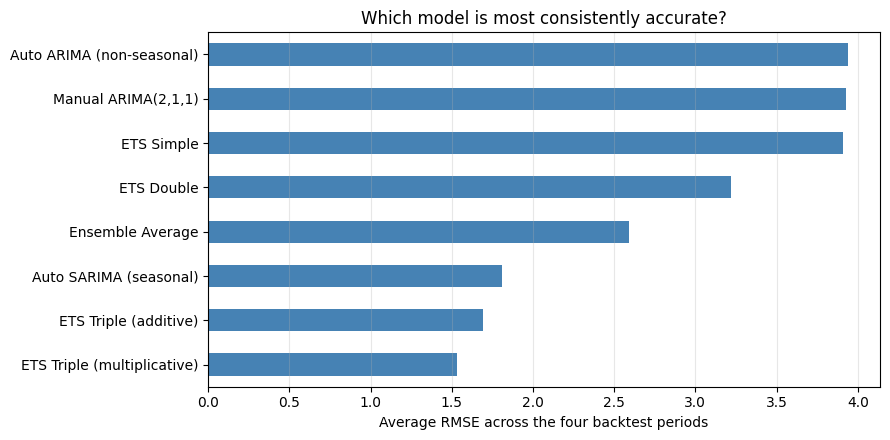

In [ ]:
ax = summary['RMSE'].sort_values().plot(kind='barh', figsize=(9, 4.5), color='steelblue')
ax.set_xlabel('Average RMSE across the four backtest periods')
ax.set_ylabel('')
ax.set_title('Which model is most consistently accurate?')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Final Recommendation

**Model selected for forecasting the next 12 months: ETS Triple (multiplicative seasonality)**

**Why.** This model had the lowest average RMSE (1.53), MAE (1.31) and MAPE (6.65%) across the four backtest periods. Its average RMSE rank was 1.00, which means it was the most accurate model in all four periods and not only on average. That consistency is what matters when the model has to forecast a period that has not been observed. Its mean error of 0.57 was also the smallest of the eight candidates, so it shows the least systematic bias.

**Additive or multiplicative seasonality.** Multiplicative seasonality outperformed additive in every period, with an average RMSE of 1.53 against 1.69. This matches the shape of the series. The height of the January peaks grows as the overall sales level grows, so the seasonal effect is better described as a percentage of the level than as a fixed quantity.

**Why the weaker models lost.** The series has both a strong upward trend and a clear 12-month seasonal cycle. The three models without a seasonal term performed worst: ETS Simple (RMSE 3.91), Manual ARIMA(2,1,1) (3.93) and Auto ARIMA non-seasonal (3.94). Their forecasts flatten into a near-straight line and miss the seasonal peaks, leaving them about 2.5 times less accurate than the seasonal models. ETS Double (3.22) improves on them by adding a trend but still has no seasonal component. All eight models had a positive mean error, so every one of them under-forecast on average. This is expected given the persistent upward trend, but the size of the bias differs sharply: 0.57 to 0.77 for the seasonal models against 2.72 to 2.77 for the non-seasonal ones.

**Caveat.** The ensemble average ranked only 4th with an RMSE of 2.59, worse than any of the three seasonal models on its own. Averaging helps when the candidate models are of similar quality. Here it diluted the two strong seasonal models with three that were structurally unable to capture seasonality. If a single-model choice had to be avoided, an ensemble restricted to the seasonal models would be more defensible.